# Run RegVelo with inferred GRN

This tutorial demonstrates how to run RegVelo in OmicVerse using the official RegVelo zebrafish neural crest RNA velocity data. The AnnData object already contains `spliced` and `unspliced` layers plus `cell_type`, `stage`, and `var["is_tf"]` annotations. Instead of using the official prebuilt GRN, this tutorial treats the object as a clean velocity dataset and infers a TF-target prior GRN directly from the expression matrix.

The workflow is:

1. Load the official RegVelo `zebrafish_nc()` velocity data.
2. Restrict the gene space while preserving annotated TFs.
3. Infer a prior GRN with `ov.single.grn()` and store it in `adata.uns`.
4. Compute `Ms` / `Mu` moment layers and align the prior GRN with `Velo.prepare_regvelo()`.
5. Train RegVelo, project the velocity field, and continue with CellRank and perturbation analysis.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import scipy.sparse as sp
import torch
import regvelo as rgv
import warnings

import omicverse as ov

warnings.filterwarnings("ignore", category=FutureWarning)
ov.plot_set(font_path="Arial")

RESULT_DIR = Path("result/regvelo_infer_grn")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Load the official RegVelo velocity data

`rgv.datasets.zebrafish_nc()` loads the official RegVelo zebrafish neural crest example. Here we only use the clean AnnData expression matrix and annotations: `spliced` / `unspliced` layers are used for velocity moments, `obs["cell_type"]` is used for downstream CellRank and visualization, and `var["is_tf"]` defines candidate regulators.

In [2]:
adata = rgv.datasets.zebrafish_nc().copy()
adata.var_names_make_unique()

print(adata)
print("layers:", list(adata.layers.keys()))
print("obs columns:", list(adata.obs.columns))
print("obsm keys:", list(adata.obsm.keys()))
print("TF annotations:", int(adata.var["is_tf"].astype(bool).sum()))

AnnData object with n_obs × n_vars = 697 × 8012
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf'
    uns: 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
layers: ['ambiguous', 'matrix', 'spliced', 'unspliced']
obs columns: ['initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage']
obsm keys: ['X_pca', 'X_umap']
TF annotations: 125


## Control gene scale and define candidate regulators

GRN inference and RegVelo training are both too expensive for a tutorial-sized run across the full gene space. Here we keep a set of highly variable genes from the spliced layer and force-retain all genes marked by `var["is_tf"]`. This keeps the tutorial manageable while preventing key regulators from being filtered out before TF perturbation.

In [3]:
n_top_genes = 2500
spliced = adata.layers["spliced"]
spliced = spliced.toarray() if sp.issparse(spliced) else np.asarray(spliced)

gene_means = spliced.mean(axis=0)
gene_vars = spliced.var(axis=0)
expressed_idx = np.where(gene_means > 0)[0]
ranked_idx = expressed_idx[np.argsort(gene_vars[expressed_idx])]
hvg_idx = ranked_idx[-min(n_top_genes, len(ranked_idx)):]

tf_mask = adata.var["is_tf"].astype(bool).to_numpy()
tf_idx = np.where(tf_mask)[0]
keep_idx = np.union1d(hvg_idx, tf_idx)
adata = adata[:, keep_idx].copy()

regulators = adata.var_names[adata.var["is_tf"].astype(bool)].tolist()
print("genes kept:", adata.n_vars)
print("candidate TFs:", len(regulators))
print("example TFs:", regulators[:10])

genes kept: 2555
candidate TFs: 125
example TFs: ['otx1', 'twist1b', 'jdp2a', 'otx2a', 'alx4a', 'erf', 'hoxa9a', 'hoxb10a', 'hnf1ba', 'sox19a']


## Infer the prior GRN

RegVelo expects a prior edge list with `TF`, `target`, and `importance` columns. OmicVerse provides the direct `ov.single.grn()` entry point, which can return this three-column table from an AnnData expression matrix. When `key_added` is set, the result is also written to `adata.uns`:

- `ov.single.grn(method="grnboost2")`: arboreto GRNBoost2, fast and suitable for tutorial-scale runs.
- `ov.single.grn(method="genie3")`: arboreto GENIE3.
- `ov.single.grn(method="regdiffusion")`: RegDiffusion-backed GRN inference, if the optional dependency is available.

This tutorial uses GRNBoost2 so that the entire RegVelo flow remains lightweight and reproducible.

In [4]:
prior_edges = ov.single.grn(
    adata,
    method="grnboost2",
    regulators=regulators,
    layer="spliced",
    top=120,
    seed=42,
    n_workers=2,
    threads=2,
    key_added="grnboost2_prior",
)

prior_edges = adata.uns["grnboost2_prior"]
prior_edges.to_csv(RESULT_DIR / "zebrafish_grnboost2_prior.csv", index=False)
prior_edges.head()

      TF   target  importance
0  zic2b     lfng   14.689011
1  zic2b    gdf6a   14.138430
2  zic2b  tuba8l3   13.809170
3  zic2b    pax3a   13.774076
4  zic2b    sox9b   13.505762

In [5]:
print("GRN method: GRNBoost2")
print("prior edges:", prior_edges.shape)
print("TFs in prior:", prior_edges["TF"].nunique())
print("targets in prior:", prior_edges["target"].nunique())
print("saved in adata.uns:", "grnboost2_prior" in adata.uns)
print("GRN metadata:", adata.uns["grnboost2_prior_params"])
print("saved prior:", RESULT_DIR / "zebrafish_grnboost2_prior.csv")
print(prior_edges.groupby("TF")["target"].nunique().sort_values(ascending=False).head(10))

GRN method: GRNBoost2
prior edges: (15000, 3)
TFs in prior: 125
targets in prior: 2532
saved in adata.uns: True
GRN metadata: {'method': 'grnboost2', 'layer': 'spliced', 'top': 120, 'log': True, 'seed': 42, 'n_workers': 2, 'threads': 2, 'n_edges': 15000, 'n_regulators': 125}
saved prior: result/regvelo_infer_grn/zebrafish_grnboost2_prior.csv
TF
alx4a       120
nr4a2b      120
roraa       120
rarga       120
pparab      120
pknox2      120
pknox1.2    120
pbx1a       120
pax2b       120
patz1       120
Name: target, dtype: int64


## Compute `Ms` / `Mu` and align the prior GRN

`Velo.prepare_regvelo()` is the RegVelo preparation step in OmicVerse. It computes neighbors and moments, generates `Ms` and `Mu`, runs gene preprocessing, aligns the edge-list prior to the final retained gene set, and writes the aligned network to `adata.uns["skeleton"]`.

In [6]:
velo_prep = ov.single.Velo(adata)
prior_grn, regulators = velo_prep.prepare_regvelo(
    prior_edges,
    regulators=regulators,
    n_neighbors=30,
    n_pcs=50,
    moment_backend="scvelo",
    prior_orientation="target_by_regulator",
)
adata = velo_prep.adata

print(adata)
print("layers:", list(adata.layers.keys()))
print("Ms/Mu present:", "Ms" in adata.layers, "Mu" in adata.layers)
print("prior GRN shape:", prior_grn.shape)
print("retained regulators:", len(regulators), regulators[:10])
print("RegVelo prep metadata:", adata.uns["regvelo_prepare"])

In Velo module, you should keep all genes' expression not normalized.
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 30
   Method: umap
   Metric: euclidean
   PCs used: 50
   🔍 Computing neighbor distances...
   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 697 cells with 30 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 2.1172s                                                 │
│  Shape:    697 x 2,555 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighb

AnnData object with n_obs × n_vars = 697 × 997
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'cell_type_colors', 'grnboost2_prior', 'grnboost2_prior_params', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', 'regvelo_regulators'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity'
    obsp: 'distances', 'connectivities'
layers: ['ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity']
Ms/Mu present: True True
prior GRN shape: (997, 997)
retained regulators: 81 ['alx4a', 'alx4b', 'arntl1b', 'bach2b', 'bhlhe40', 'bhlhe41', 'dlx1a', 'e2f7', 'ebf1b', 'ebf3a']
RegVelo prep metadata: {'n_neighb

## Run RegVelo

The next step trains RegVelo and writes the inferred velocity to `layers["velo_regvelo"]`. For a quick smoke test, reduce `max_epochs`; for real analysis, increase the number of epochs and inspect convergence.

In [7]:
if torch.cuda.is_available():
    accelerator = "gpu"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    accelerator = "mps"
else:
    accelerator = "cpu"

adata = ov.single.velocity(
    adata,
    method="regvelo",
    prior_grn=prior_grn,
    regulators=regulators,
    velocity_key="velo_regvelo",
    spliced_layer="Ms",
    unspliced_layer="Mu",
    n_samples=30,
    model_save_path=str(RESULT_DIR / "model"),
    model_overwrite=True,
    regvelo_kwargs={
        "soft_constraint": False,
    },
    train_kwargs={
        "max_epochs": 50,
        "accelerator": accelerator,
        "devices": 1,
    },
    compute_velocity_graph=True,
    compute_velocity_embedding=True,
    basis="umap",
    graph_kwargs={
        "xkey": "Ms",
        "n_jobs": 4,
    },
)

print(adata.uns["regvelo"])
print("velocity layers:", [key for key in adata.layers.keys() if "velo" in key or key == "velocity"])
print("velocity embeddings:", [key for key in adata.obsm.keys() if "velo" in key])

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In Velo module, you should keep all genes' expression not normalized.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


computing velocity graph (using 4/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:04) --> added 
    'velo_regvelo_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_regvelo_umap', embedded velocity vectors (adata.obsm)
{'spliced_layer': 'Ms', 'unspliced_layer': 'Mu', 'n_samples': 30, 'batch_size': 697, 'velocity_key': 'velo_regvelo', 'n_regulators': 81, 'model_load_path': None, 'model_save_path': 'result/regvelo_infer_grn/model', 'model_overwrite': True, 'reuse_regvelo_output': False, 'reused_regvelo_output': False}
velocity layers: ['velocity', 'latent_time_velovi', 'velo_regvelo']
velocity embeddings: ['velo_regvelo_umap']


## Visualize the RegVelo vector field

In the zebrafish data, the main cell-state annotation is `obs["cell_type"]`. Here `ov.pl.embedding()` draws the cell embedding, and `ov.pl.add_streamplot()` overlays the RegVelo vector field stored in `obsm["velo_regvelo_umap"]`.

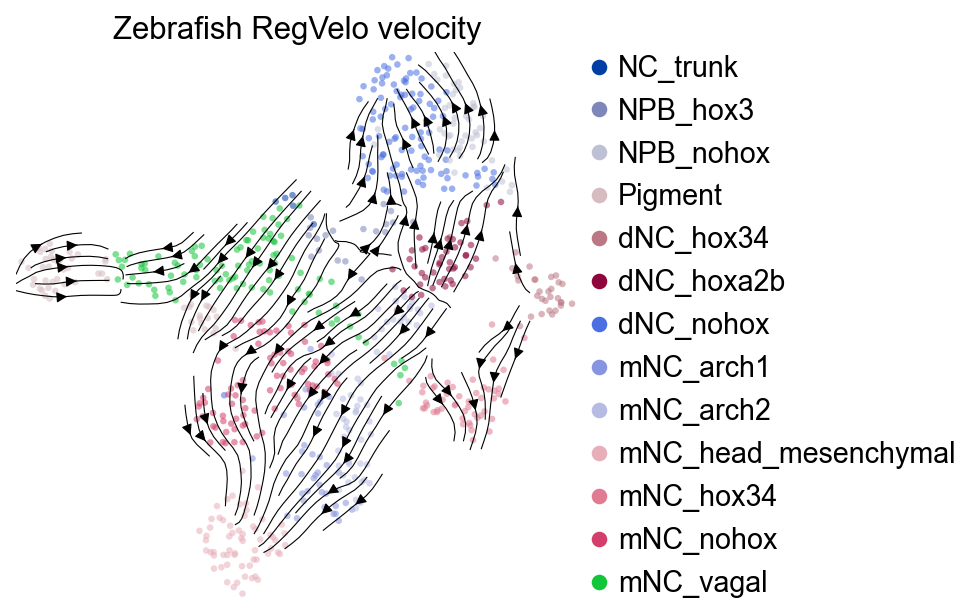

In [8]:
fig = ov.plt.figure(figsize=(4.5, 4.5))
ax = ov.plt.subplot(1, 1, 1)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=ax,
    show=False,
    size=35,
    alpha=0.55,
    frameon=False,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=ax,
)
ov.plt.title("Zebrafish RegVelo velocity")
ov.plt.show()

## Check latent time and regulon size

Diagnostic layers exported by RegVelo can differ across versions. This cell first checks whether `fit_t` exists before plotting latent time, then summarizes the retained prior regulon sizes from `adata.uns["skeleton"]`.

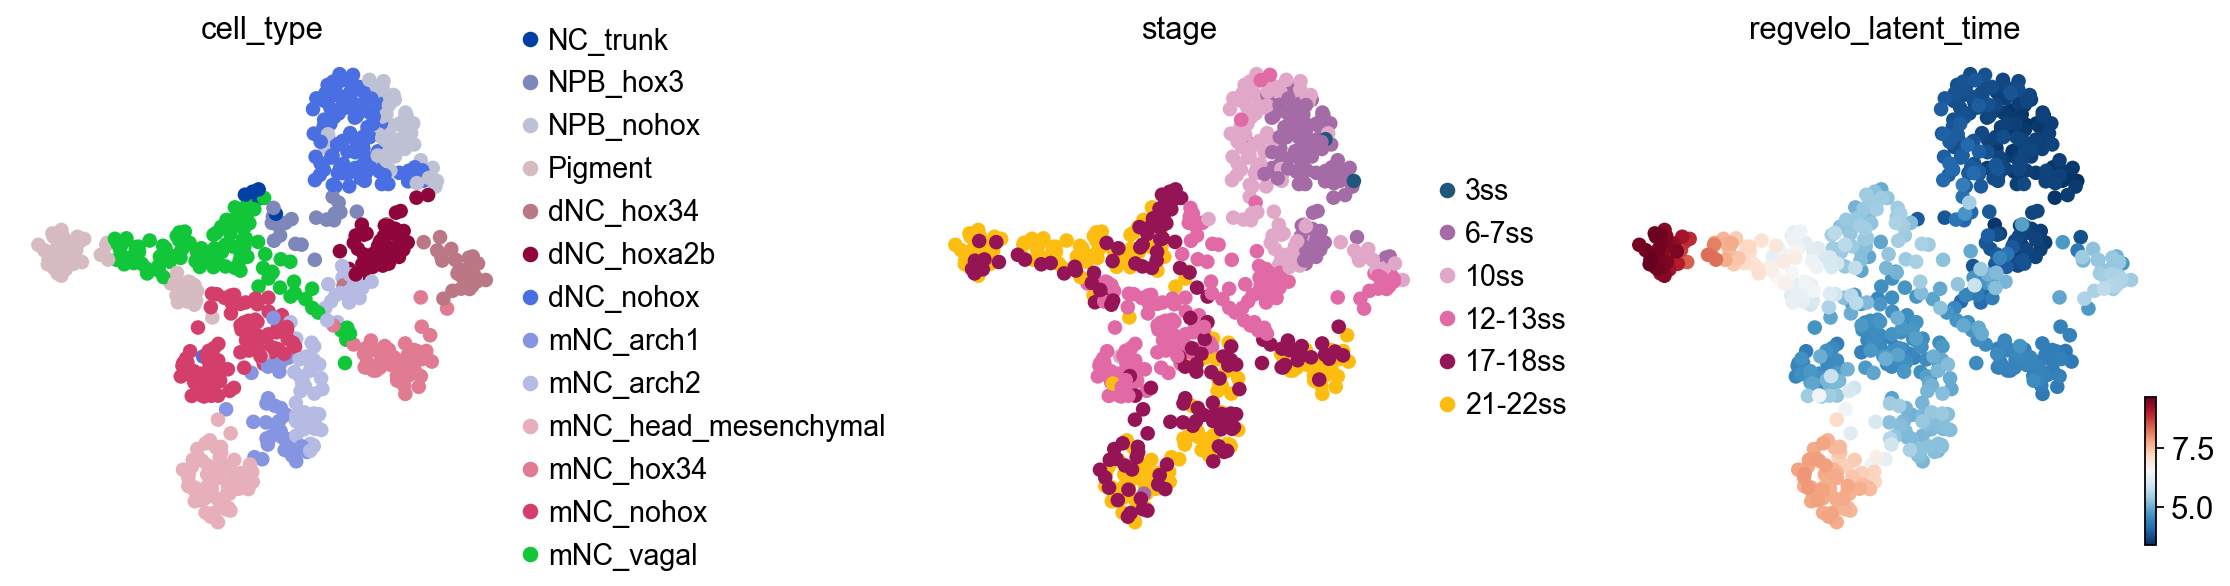

Gene
ppm1h                12
col12a1a             12
zgc:112332           12
hoxb5b               12
si:ch211-199g17.2    11
plpp3                11
tuba8l2              11
ptprfa               10
tcf12                10
msx3                 10
hoxa9b               10
sox9b                10
rflnb                10
efemp2b              10
cspg5a               10
dtype: int64

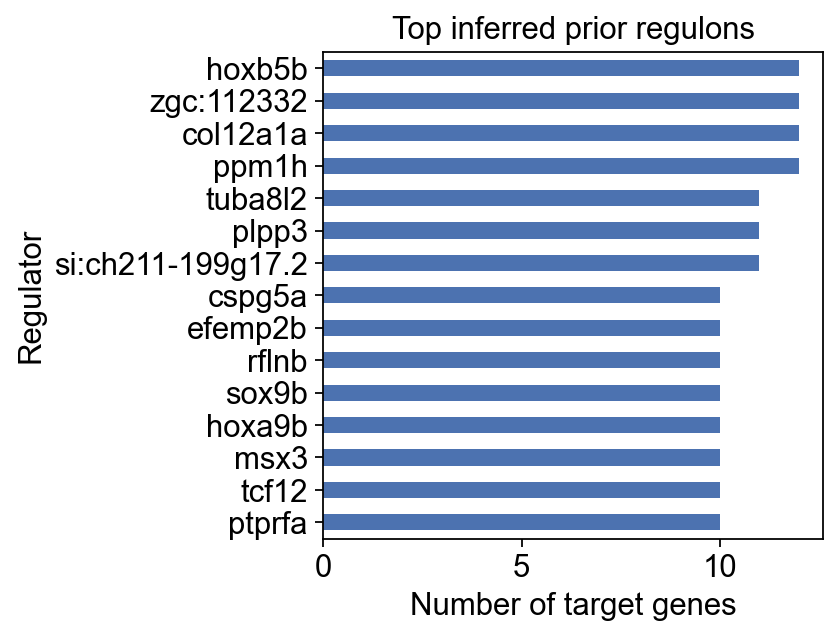

In [9]:
if "fit_t" in adata.layers:
    fit_t = np.asarray(adata.layers["fit_t"])
    adata.obs["regvelo_latent_time"] = fit_t.mean(axis=1)
    latent_colors = ["cell_type", "regvelo_latent_time"]
    if "stage" in adata.obs:
        latent_colors.insert(1, "stage")
    ov.pl.embedding(
        adata,
        basis="X_umap",
        color=latent_colors,
        ncols=min(3, len(latent_colors)),
        frameon=False,
        show=False,
    )
    ov.plt.show()
else:
    print("RegVelo did not export layers['fit_t'] in this run.")

skeleton = adata.uns["skeleton"]
if isinstance(skeleton, pd.DataFrame):
    regulon_size = (skeleton != 0).sum(axis=0).sort_values(ascending=False)
else:
    skeleton_array = np.asarray(skeleton)
    regulon_size = pd.Series(
        (skeleton_array != 0).sum(axis=0),
        index=adata.var_names[: skeleton_array.shape[1]],
    ).sort_values(ascending=False)

regulon_size_summary = regulon_size.head(15)
display(regulon_size_summary)

ax = regulon_size_summary.sort_values().plot.barh(figsize=(4, 4), color="#4c72b0")
ax.set_xlabel("Number of target genes")
ax.set_ylabel("Regulator")
ax.set_title("Top inferred prior regulons")
ov.plt.show()

## CellRank fate analysis from RegVelo velocities

The `cell_type` annotation in the zebrafish neural crest data contains several neural-crest and pigment-related states. We start from a conservative set of terminal states and keep only those present in the current object.

This section directly computes fate probabilities; the downstream commitment score, fate perturbation, and single-cell perturbation-effect sections all reuse these CellRank results.

In [10]:
requested_terminal_states = ["mNC_head_mesenchymal", "mNC_hox34", "Pigment"]
requested_terminal_states = [state for state in requested_terminal_states if state in set(adata.obs["cell_type"])]
if not requested_terminal_states:
    raise ValueError("None of the requested terminal states were found in adata.obs['cell_type'].")

print("requested terminal states:", requested_terminal_states)

estimator = ov.single.cellrank_fate(
    adata,
    velocity_key="velo_regvelo",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=requested_terminal_states,
    n_states=max(4, len(requested_terminal_states)),
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    fate_kwargs={"solver": "direct", "use_petsc": False},
    clean=True,
    plot=False,
)

cellrank_state = adata.uns["velocity_cellrank"]
terminal_states = list(cellrank_state.get("terminal_states") or [])
if not terminal_states:
    raise ValueError(
        "None of the requested terminal states are CellRank macrostates. "
        f"Valid macrostates: {ov.single.state_names(estimator)}"
    )

macrostate_names = ov.single.state_names(estimator)
print("terminal states used:", terminal_states)
print("macrostates:", macrostate_names)

requested terminal states: ['mNC_head_mesenchymal', 'mNC_hox34', 'Pigment']
In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

terminal states used: ['mNC_head_mesenchymal', 'mNC_hox34', 'Pigment']
macrostates: ['mNC_hox34', 'Pigment', 'mNC_head_mesenchymal', 'NPB_nohox']


`ov.pl.cell_fate()` reuses the CellRank result stored in `adata.uns["velocity_cellrank"]["estimator"]`. It only visualizes terminal states and does not recompute macrostates.

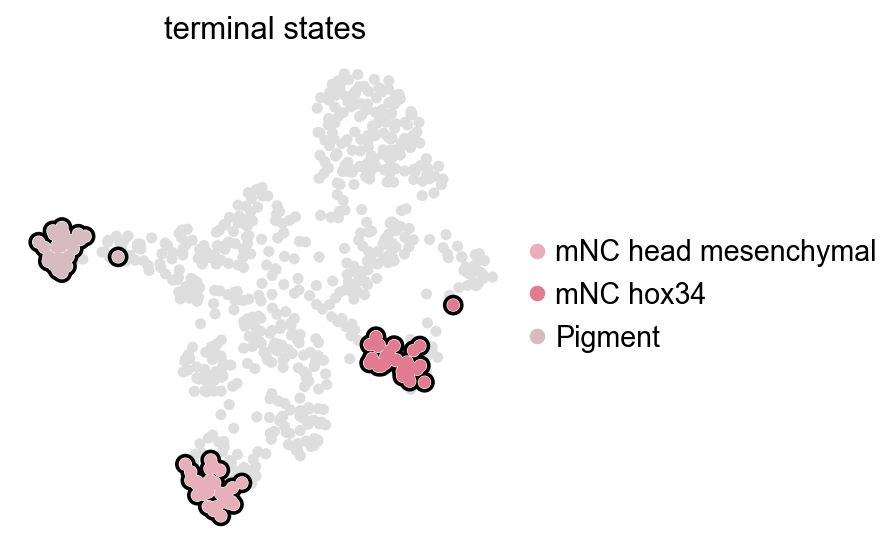

In [11]:
ov.pl.cell_fate(estimator, which="terminal", basis="umap")

## Fate probabilities and commitment score

CellRank computes per-cell fate probabilities toward terminal states. The RegVelo perturbation workflow also uses these probabilities to compute a commitment score; lower values usually indicate more committed cell fates.

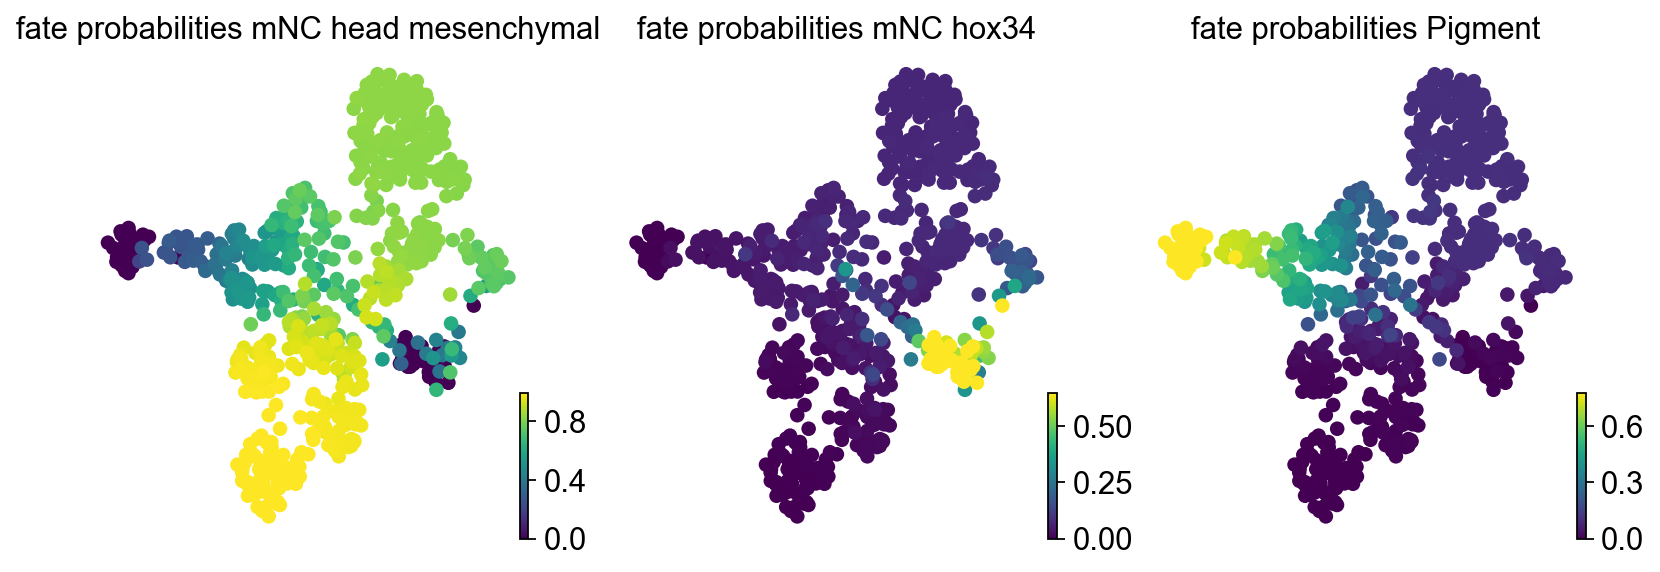

In [12]:
estimator.plot_fate_probabilities(
    same_plot=False,
    basis="umap",
)

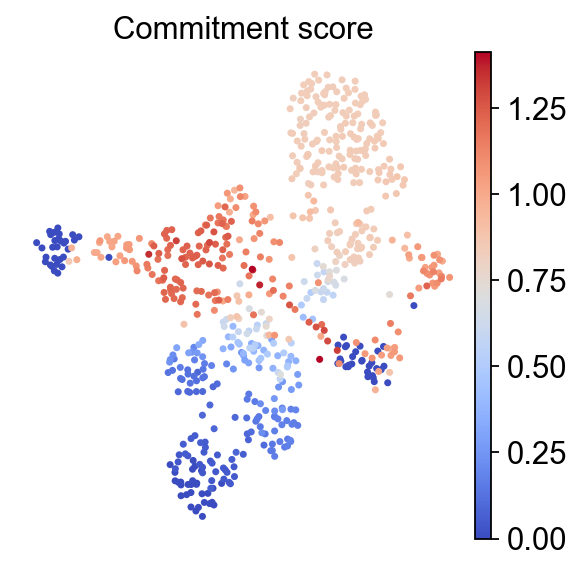

In [13]:
rgv.pl.commitment_score(
    adata=adata,
    lineage_key="lineages_fwd",
    frameon=False,
    s=40,
    cmap="coolwarm",
    title="Commitment score",
)

## Native RegVelo TF regulon blockade

The reproducibility workflow uses the saved RegVelo model for TF perturbation and regulatory screening. Because the model has been saved to `RESULT_DIR / "model"`, this section calls RegVelo's native in silico blockade API directly.

In [14]:
candidate_tfs = [tf for tf in ["elf1", "nr2f5", "tfap2a", "sox10", "mitfa"] if tf in regulators]
if not candidate_tfs:
    raise ValueError("None of the candidate perturbation TFs survived RegVelo preprocessing.")

candidate_tf = candidate_tfs[0]
print("candidate TFs:", candidate_tfs)
print("single TF blockade:", candidate_tf)

perturbed_adata, perturbed_model = ov.single.Velo(adata).regvelo_perturb(
    candidate_tf,
    model=str(RESULT_DIR / "model"),
    cutoff=0.001,
    batch_size=adata.n_obs,
)

perturbed_velo = ov.single.Velo(perturbed_adata)
perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=4)
perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")
print(perturbed_adata)

candidate TFs: ['elf1', 'nr2f5', 'tfap2a', 'sox10', 'mitfa']
single TF blockade: elf1
In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_infer_grn/model/model.pt already downloaded                                           


In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 4/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
AnnData object with n_obs × n_vars = 697 × 997
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage', 'velo_regvelo_self_transition', 'regvelo_latent_time', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'commitment_score', 'velocity_self_transition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_beta', 'fit_gamma', 'fit_scaling', 'velo_regvelo_genes'
    uns: 'cell_type_colors', 'grnboost2_prior', 'grnboost2_prior_params', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', '

## Compare baseline and perturbed velocity fields

After perturbation, the same UMAP coordinates are reused to compare the baseline RegVelo vector field with the TF-blockade vector field.

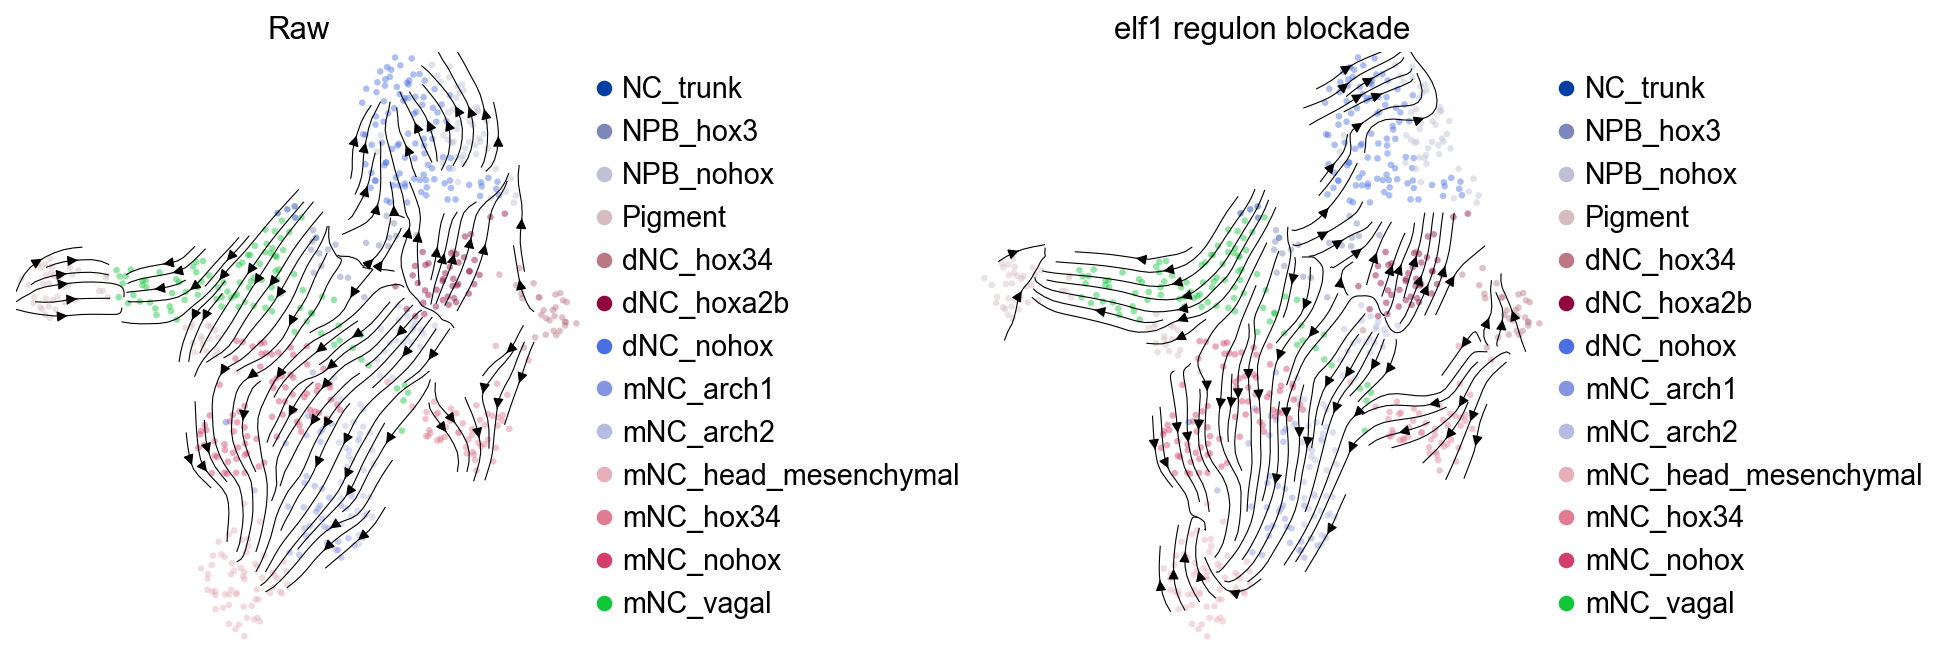

In [15]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[0],
    show=False,
    size=35,
    alpha=0.45,
    frameon=False,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=axes[0],
)
axes[0].set_title("Raw")

ov.pl.embedding(
    perturbed_adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[1],
    show=False,
    size=35,
    alpha=0.45,
    frameon=False,
)
ov.pl.add_streamplot(
    perturbed_adata,
    basis="X_umap",
    velocity_key="velocity_umap",
    ax=axes[1],
)
axes[1].set_title(f"{candidate_tf} regulon blockade")
ov.plt.show()

## Quantify local TF blockade effects

`ov.single.velocity_effect()` computes velocity cosine dissimilarity for each cell before and after perturbation. Larger values indicate stronger velocity-direction changes after TF blockade.

In Velo module, you should keep all genes' expression not normalized.


                mean    median       max
cell_type                               
Pigment     0.000179  0.000161  0.000496
dNC_hoxa2b  0.000178  0.000153  0.000552
mNC_arch1   0.000175  0.000140  0.000616
mNC_vagal   0.000169  0.000140  0.000439
mNC_arch2   0.000162  0.000148  0.000422
NPB_hox3    0.000161  0.000133  0.000545
dNC_hox34   0.000159  0.000147  0.000299
dNC_nohox   0.000155  0.000136  0.000399
NPB_nohox   0.000147  0.000127  0.000294
mNC_nohox   0.000124  0.000107  0.000327

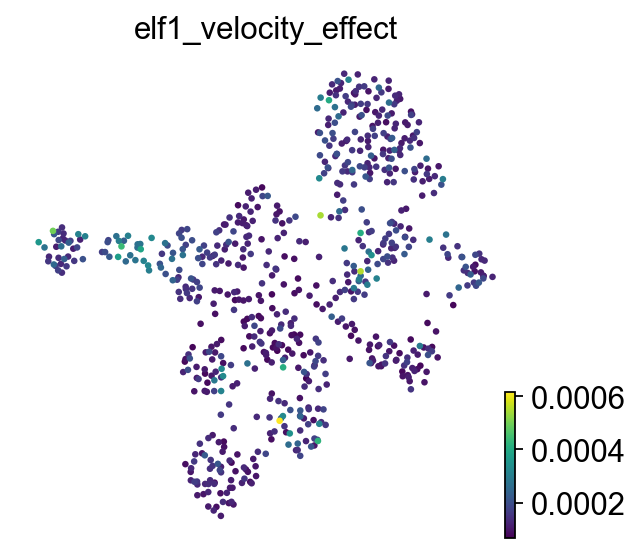

In [16]:
ov.single.velocity_effect(
    adata,
    perturbed_adata,
    baseline_velocity_key="velo_regvelo",
    perturbed_velocity_key="velocity",
    target=candidate_tf,
)

effect_col = f"{candidate_tf}_velocity_effect"
velocity_effect_summary = (
    adata.obs.groupby("cell_type", observed=True)[effect_col]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
display(velocity_effect_summary.head(10))

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=effect_col,
    cmap="viridis",
    size=35,
    frameon=False,
)

## Compare baseline and perturbed fate probabilities

CellRank fate probabilities are recomputed on the perturbed velocity field, then terminal-state probabilities are compared before and after perturbation.

In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

perturbed terminal states used: ['mNC_head_mesenchymal', 'Pigment']
perturbed macrostates: ['dNC_hox34', 'dNC_nohox', 'Pigment', 'mNC_head_mesenchymal']


                      elf1_delta_mNC_head_mesenchymal  elf1_delta_Pigment
cell_type                                                                
NC_trunk                                     0.059972            0.002121
NPB_hox3                                     0.086335           -0.014734
NPB_nohox                                    0.068109            0.004302
Pigment                                     -0.129584            0.149012
dNC_hox34                                    0.163904            0.009641
dNC_hoxa2b                                   0.069404            0.001651
dNC_nohox                                    0.066259            0.003622
mNC_arch1                                    0.025068           -0.006376
mNC_arch2                                    0.057141           -0.013248
mNC_head_mesenchymal                         0.001563           -0.000150
mNC_hox34                                    0.746698            0.035388
mNC_nohox                             

plotted fate delta: elf1_delta_Pigment


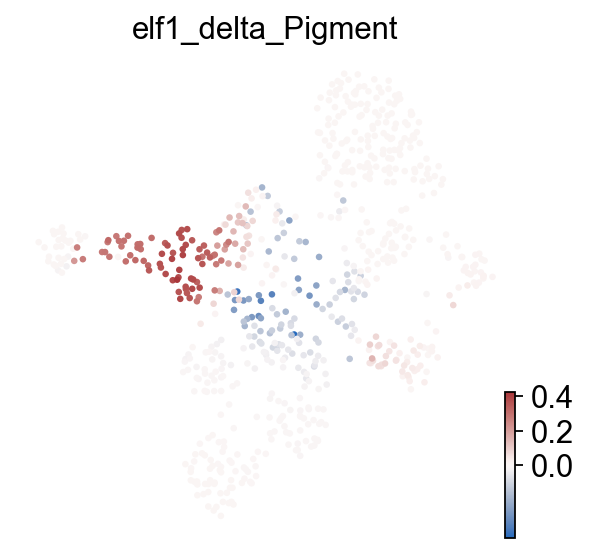

In [17]:
def lineage_to_df(adata_obj, key="lineages_fwd"):
    lineages = adata_obj.obsm[key]
    values = np.asarray(lineages)
    names = getattr(lineages, "names", None)
    if names is None:
        names = [f"lineage_{i}" for i in range(values.shape[1])]
    return pd.DataFrame(values, index=adata_obj.obs_names, columns=list(names))

perturbed_estimator = ov.single.cellrank_fate(
    perturbed_adata,
    velocity_key="velocity",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=terminal_states,
    n_states=max(4, len(terminal_states)),
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    fate_kwargs={"solver": "direct", "use_petsc": False},
    clean=True,
    plot=False,
)

perturbed_macrostate_names = ov.single.state_names(perturbed_estimator)
perturbed_terminal_states = list(
    perturbed_adata.uns["velocity_cellrank"].get("terminal_states") or []
)
if not perturbed_terminal_states:
    raise ValueError(
        f"None of the baseline terminal states are perturbed CellRank macrostates. "
        f"Valid perturbed macrostates: {perturbed_macrostate_names}"
    )

print("perturbed terminal states used:", perturbed_terminal_states)
print("perturbed macrostates:", perturbed_macrostate_names)

# RegVelo native perturbation metrics read fate probabilities directly from
# lineages_fwd. Clean non-finite entries explicitly before computing deltas
# and likelihood/t-statistic summaries.
ov.single.clean_lineages(adata, key="lineages_fwd")
ov.single.clean_lineages(perturbed_adata, key="lineages_fwd")

baseline_fate = lineage_to_df(adata)
perturbed_fate = lineage_to_df(perturbed_adata)
common_fates = list(baseline_fate.columns.intersection(perturbed_fate.columns))
if not common_fates:
    raise ValueError("No common fate probability columns were found between baseline and perturbed CellRank results.")
terminal_states_for_perturbation = common_fates

fate_delta = perturbed_fate[common_fates] - baseline_fate[common_fates]
fate_delta.columns = [f"{candidate_tf}_delta_{state}" for state in common_fates]
adata.obs = adata.obs.join(fate_delta)

fate_delta_summary = fate_delta.groupby(adata.obs["cell_type"], observed=True).mean()
display(fate_delta_summary)

target_fate = "Pigment" if "Pigment" in common_fates else common_fates[0]
target_delta_col = f"{candidate_tf}_delta_{target_fate}"
print("plotted fate delta:", target_delta_col)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=target_delta_col,
    cmap="vlag",
    vcenter=0,
    size=35,
    frameon=False,
)

RegVelo also provides a native fate-perturbation statistic for summarizing fate-probability depletion/enrichment. The current RegVelo version requires baseline and perturbed `lineages_fwd` objects to contain exactly the same terminal-state columns, so the cell below first subsets lineage columns in temporary AnnData copies and then calls `ov.single.cell_fate_perturbation()`.

In Velo module, you should keep all genes' expression not normalized.


   Depletion likelihood       p-value  FDR adjusted p-value  \
0              0.418846  9.999999e-01          9.999999e-01   
1              0.581154  7.761836e-08          1.552367e-07   

         Terminal state    TF  
0  mNC_head_mesenchymal  elf1  
1               Pigment  elf1  

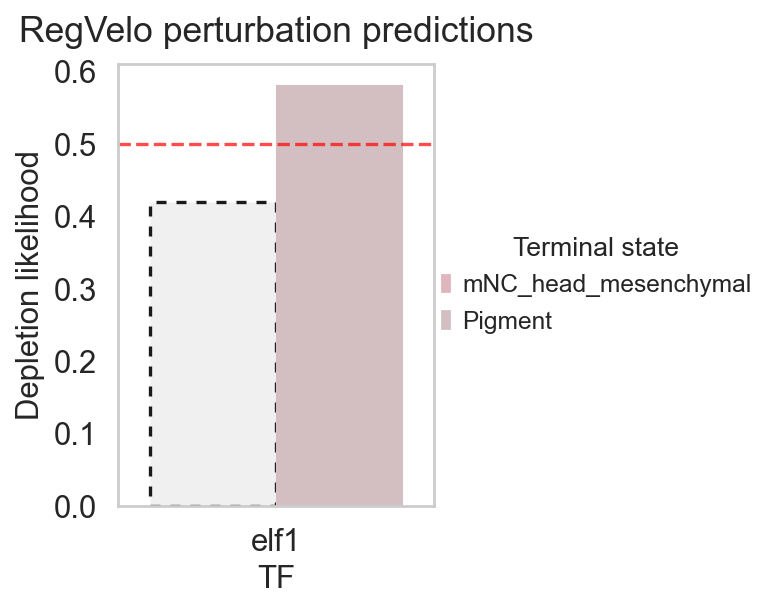

In [18]:
from cellrank import Lineage


def subset_lineages(adata_obj, names, key="lineages_fwd"):
    lineages = adata_obj.obsm[key]
    old_names = list(getattr(lineages, "names", [f"lineage_{i}" for i in range(np.asarray(lineages).shape[1])]))
    keep = [name for name in names if name in old_names]
    if not keep:
        raise ValueError("No requested lineage columns were found.")
    idx = [old_names.index(name) for name in keep]
    values = np.asarray(lineages, dtype=float)[:, idx]
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    row_sums = values.sum(axis=1, keepdims=True)
    nonzero = row_sums[:, 0] > 0
    values[nonzero] = values[nonzero] / row_sums[nonzero]
    values[~nonzero] = 1.0 / values.shape[1]
    colors = getattr(lineages, "colors", None)
    if colors is not None:
        colors = [colors[i] for i in idx]
    adata_obj.obsm[key] = Lineage(values, names=keep, colors=colors)
    return keep

baseline_metric = adata.copy()
perturbed_metric = perturbed_adata.copy()
metric_terminal_states = subset_lineages(baseline_metric, terminal_states_for_perturbation)
subset_lineages(perturbed_metric, metric_terminal_states)

fate_stats = ov.single.cell_fate_perturbation(
    baseline_metric,
    perturbed={candidate_tf: perturbed_metric},
    terminal_states=metric_terminal_states,
    score_method="likelihood",
)
display(fate_stats)

rgv.pl.cellfate_perturbation(
    adata=baseline_metric,
    df=fate_stats,
    color_label="cell_type",
    figsize=(5, 4),
)

## Single-cell perturbation effect

`ov.single.perturbation_effect()` writes the per-cell fate-probability difference back to `adata.obs`. Negative values indicate that the probability of reaching a terminal fate decreases, while positive values indicate an increase.

In [19]:
adata = ov.single.perturbation_effect(
    adata,
    perturbed_adata,
    terminal_states=terminal_states_for_perturbation,
)

effect_cols = [col for col in adata.obs.columns if col.startswith("perturbation effect on ")]
print(effect_cols)

In Velo module, you should keep all genes' expression not normalized.
['perturbation effect on mNC_head_mesenchymal', 'perturbation effect on Pigment']


                      perturbation effect on mNC_head_mesenchymal  \
cell_type                                                           
NC_trunk                                                 0.059972   
NPB_hox3                                                 0.086335   
NPB_nohox                                                0.068109   
Pigment                                                 -0.129584   
dNC_hox34                                                0.163904   
dNC_hoxa2b                                               0.069404   
dNC_nohox                                                0.066259   
mNC_arch1                                                0.025068   
mNC_arch2                                                0.057141   
mNC_head_mesenchymal                                     0.001563   
mNC_hox34                                                0.746698   
mNC_nohox                                                0.036333   
mNC_vagal                         

plotted perturbation effect: perturbation effect on Pigment


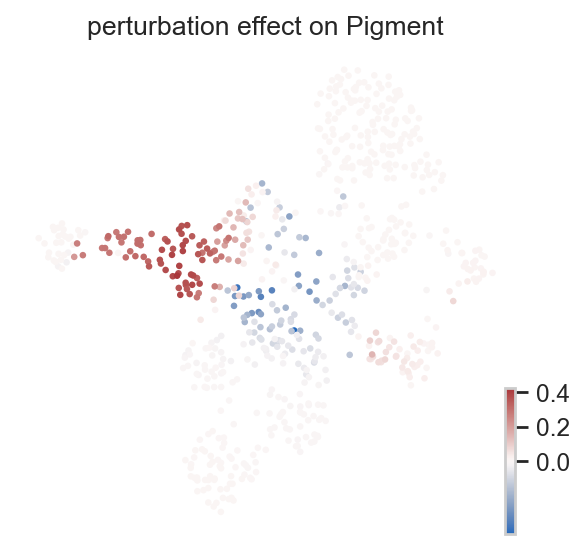

In [20]:
perturbation_effect_summary = (
    adata.obs.groupby("cell_type", observed=True)[effect_cols]
    .mean()
    .sort_index()
)
display(perturbation_effect_summary)

preferred_effect = "perturbation effect on Pigment"
effect_key = preferred_effect if preferred_effect in effect_cols else effect_cols[0]
print("plotted perturbation effect:", effect_key)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=effect_key,
    cmap="vlag",
    vcenter=0,
    size=35,
    frameon=False,
)

## Multiple TF blockade

The `tf` argument of `regvelo_perturb()` can also receive multiple TFs. Multi-TF perturbation is useful for exploring combinatorial regulation, but it is best to first confirm that all selected TFs are retained in the regulator list of the current model.

In [21]:
multi_tfs = [tf for tf in ["elf1", "nr2f5", "tfap2a", "sox10", "mitfa"] if tf in regulators][:2]
print("multi TF blockade:", multi_tfs)

multi_perturbed_adata, multi_perturbed_model = ov.single.Velo(adata).regvelo_perturb(
    multi_tfs,
    model=str(RESULT_DIR / "model"),
    cutoff=0.001,
    batch_size=adata.n_obs,
)

multi_perturbed_velo = ov.single.Velo(multi_perturbed_adata)
multi_perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=4)
multi_perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")

multi TF blockade: ['elf1', 'nr2f5']
In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_infer_grn/model/model.pt already downloaded                                           


In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 4/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


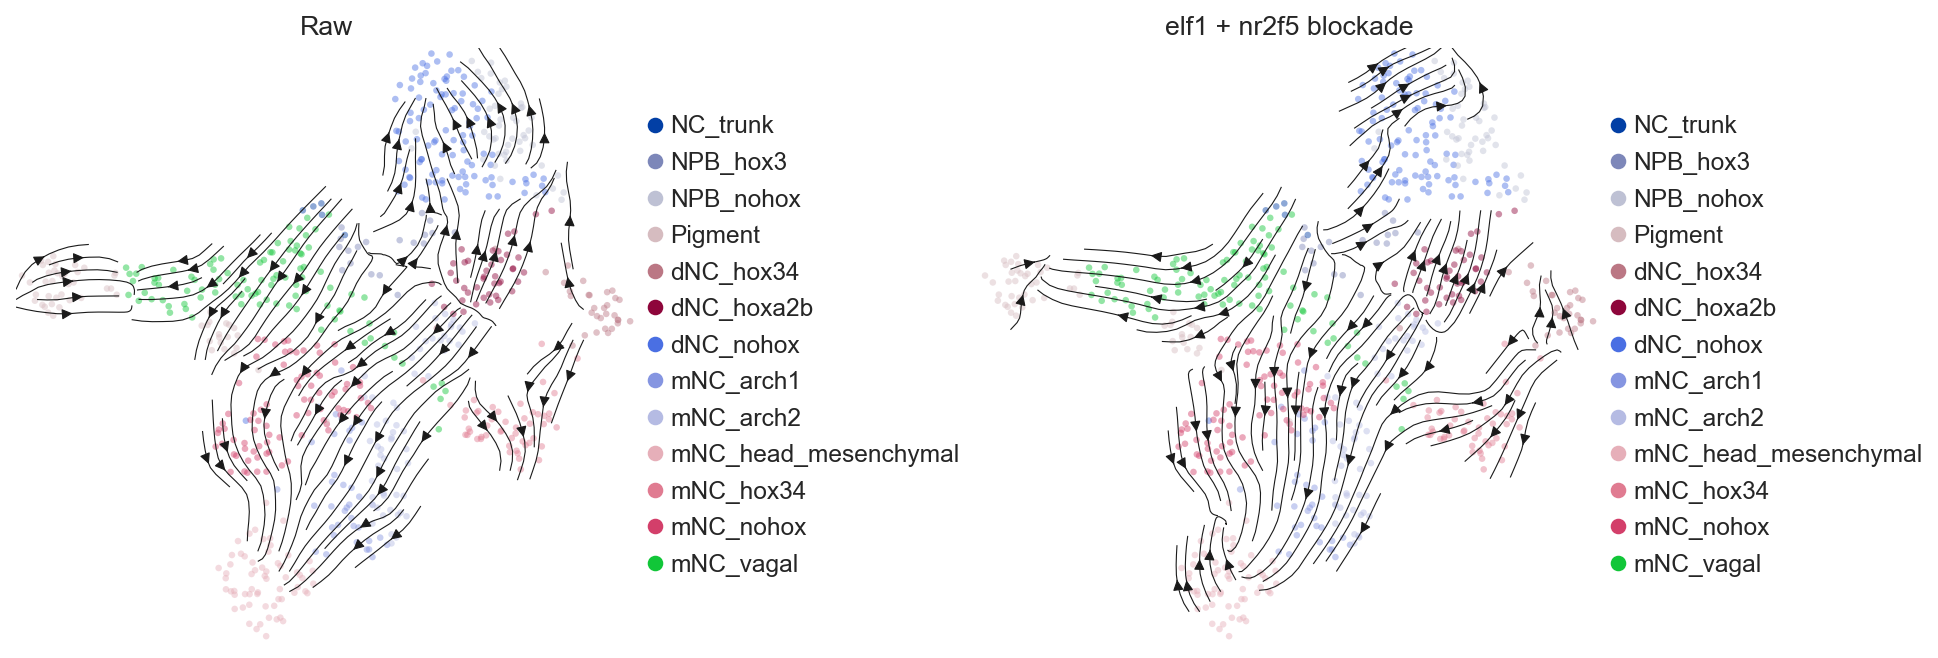

In [22]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ov.pl.embedding(adata, basis="X_umap", color="cell_type", ax=axes[0], show=False, size=35, alpha=0.45, frameon=False)
ov.pl.add_streamplot(adata, basis="X_umap", velocity_key="velo_regvelo_umap", ax=axes[0])
axes[0].set_title("Raw")

ov.pl.embedding(
    multi_perturbed_adata,
    basis="X_umap", color="cell_type",
    ax=axes[1],
    show=False,
    size=35,
    alpha=0.45,
    frameon=False
)
ov.pl.add_streamplot(multi_perturbed_adata, basis="X_umap", velocity_key="velocity_umap", ax=axes[1])
axes[1].set_title(" + ".join(multi_tfs) + " blockade")
ov.plt.show()

## Save the result

The saved AnnData contains `Ms`, `Mu`, `velo_regvelo`, RegVelo metadata, CellRank fate probabilities, TF perturbation summaries, and single-cell perturbation effects. CellRank estimator/kernel objects, the in-memory RegVelo model, and perturbation AnnData objects cannot be written directly to h5ad, so the object is sanitized before saving.

In [23]:
adata_to_save = adata.copy()
adata_to_save.uns["velocity_cellrank"] = {
    key: value
    for key, value in adata_to_save.uns["velocity_cellrank"].items()
    if key not in {"estimator", "kernel"}
}

adata_to_save.uns.pop("regvelo_model", None)

adata_to_save.write(RESULT_DIR / "zebrafish_regvelo_infer_grn.h5ad")
print(RESULT_DIR / "zebrafish_regvelo_infer_grn.h5ad")

result/regvelo_infer_grn/zebrafish_regvelo_infer_grn.h5ad
